In [665]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import re
import fnmatch
import matplotlib.pyplot as plt
from functools import reduce
from bs4 import BeautifulSoup
import requests
import osmnx as ox
from API_KEY import get_OneMap_token
import networkx as nx
import copy
import matplotlib
import matplotlib as mpl
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow

import importlib

import helper_functions.utils as utils
import helper_functions.serviceArea
import helper_functions.amenities_dict
import helper_functions.OneMapAPI
import helper_functions.residential_attributes
import helper_functions.flood
import helper_functions.mrt_buffer
import helper_functions.drainage_work
import helper_functions.data
import helper_functions.DEM

importlib.reload(helper_functions.serviceArea)
importlib.reload(helper_functions.amenities_dict)
importlib.reload(helper_functions.OneMapAPI)
importlib.reload(helper_functions.residential_attributes)
importlib.reload(helper_functions.flood)
importlib.reload(helper_functions.mrt_buffer)
importlib.reload(helper_functions.drainage_work)
importlib.reload(helper_functions.data)
importlib.reload(helper_functions.DEM)

import helper_functions.serviceArea as serviceArea
import helper_functions.amenities_dict as amenities_dict
import helper_functions.plot_utils as plot_utils
import helper_functions.OneMapAPI as OneMapAPI
import helper_functions.residential_attributes as residential_attributes
import helper_functions.flood as Flood
import helper_functions.mrt_buffer as mrt_buffer
import helper_functions.drainage_work as drainage_work
import helper_functions.data as Data
import helper_functions.DEM as DEM

# Import Data

## Import planning area and subzone

Index(['Name', 'PLN_AREA_N', 'PLN_AREA_C', 'REGION_N', 'REGION_C', 'geometry'], dtype='object')
Index(['Name', 'SUBZONE_NO', 'SUBZONE_N', 'SUBZONE_C', 'PLN_AREA_N',
       'PLN_AREA_C', 'REGION_N', 'REGION_C', 'geometry'],
      dtype='object')


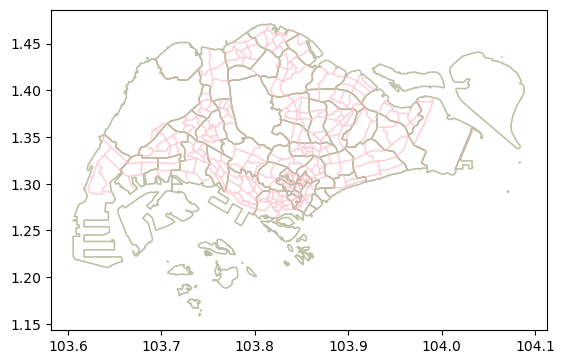

In [666]:
planningArea_shp = gpd.read_file(Data.PLANNING_AREA_FP)
subzone_shp = gpd.read_file(Data.SUBZONE_FP)
fig, ax = plt.subplots(1,1)
for shp,c in zip([planningArea_shp,subzone_shp],["green","pink"]):
    print(shp.columns)
    shp.plot(fc="none",ec=c,ax=ax,alpha=0.5)
plt.show()

## Import network

In [667]:
G_walk = ox.load_graphml(Data.G_WALK_FP)
G_car = ox.load_graphml(Data.G_CAR_FP)

## Import residential

Add spatial attributes

In [668]:
# residential_df = residential_attributes.get_private_residential_df(r"Exported_Data\Residential_transaction_2014_2024.csv")
residential_df = Data.get_private_residential_df(Data.PRIVATE_RESIDENTIAL_FP)
# add subzone
# spatial join with subzone
residential_df = residential_df.sjoin(subzone_shp[["SUBZONE_N","geometry"]],how="left")
# replace project names with NA with their address before unit number
residential_df["Project Name"] = residential_df.apply(lambda x: residential_attributes.get_project_name(x),axis=1)
# add nodesID for properties
residential_df['nodesID_property'] = ox.nearest_nodes(G_car,X=residential_df['LONGITUDE'], Y=residential_df['LATITUDE'])
# simplify Tenure and Completion Date
residential_df['Tenure'] = residential_df['Tenure'].astype(str).apply(lambda x: residential_attributes.get_tenure(x))
residential_df['Building Age'] = residential_attributes.get_building_age(residential_df['Completion Date'], residential_df['year'])
print("length of residential df: ", len(residential_df))
# drop index_right
residential_df = residential_df.drop(columns=["index_right"])
residential_df.head()

length of residential df:  267452


,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,X,Y,LATITUDE,LONGITUDE,year,month,geometry,SUBZONE_N,nodesID_property,Building Age
0,481 YIO CHU KANG ROAD #05-02,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,28883.630900,40954.900104,1.386656,103.841259,2014,1,POINT (103.84126 1.38666),YIO CHU KANG WEST,437138895,17.0
1,52 HUME AVENUE #01-16,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,20479.219140,37907.302875,1.359094,103.765739,2014,1,POINT (103.76574 1.35909),HILLVIEW,7495834879,12.0
2,41 BRIGHT HILL DRIVE #14-01,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New Sale,Strata,68.0,15456,...,27661.184826,37765.008907,1.357808,103.830274,2014,1,POINT (103.83027 1.35781),UPPER THOMSON,4727949662,2014.0
3,103 HILLVIEW RISE #10-11,730000,516.67,1413,2014-01-03,103 HILLVIEW RISE #10-11,New Sale,Strata,48.0,15208,...,20304.463939,38537.214606,1.364790,103.764169,2014,1,POINT (103.76417 1.36479),HILLVIEW,6540315280,2014.0
4,628 UPPER THOMSON ROAD #05-61,2518000,3035.45,830,2014-01-03,628 UPPER THOMSON ROAD #05-61,Resale,Strata,282.0,8929,...,27381.798079,40248.119710,1.380264,103.827764,2014,1,POINT (103.82776 1.38026),TAGORE,311986889,2.0


## Import flood data

In [669]:
# historical flood
flood_df = Data.get_flood_df(Data.FLOOD_FP)
# update frroms from 2013 to 2025
# spatial join with subzone
flood_df = flood_df.sjoin(subzone_shp[["SUBZONE_N","PLN_AREA_N","geometry"]],how="left")
flood_df.head()

,Flood_Date,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,flooded_location,geometry,index_right,SUBZONE_N,PLN_AREA_N
0,2013-01-02,58589 (BUS STOP),NaN,GAMBAS AVE,58589 (BUS STOP),58589 (BUS STOP),NIL,25757.985102,47244.565267,1.443537,103.813172,58589 (Bus stop),POINT (103.81317 1.44354),325,MANDAI EAST,MANDAI
1,2013-02-08,ONE COMMONWEALTH,1,COMMONWEALTH LANE,ONE COMMONWEALTH,1 COMMONWEALTH LANE ONE COMMONWEALTH SINGAPORE...,149544,23935.142214,31862.576376,1.304428,103.796794,One Commonwealth,POINT (103.79679 1.30443),226,HOLLAND DRIVE,QUEENSTOWN
2,2013-02-08,42059 (BUS STOP),NaN,DUNEARN RD,42059 (BUS STOP),42059 (BUS STOP),NIL,22373.582277,35402.855413,1.336445,103.782762,42059,POINT (103.78276 1.33644),152,SWISS CLUB,BUKIT TIMAH
3,2013-04-28,ANSAR GARDEN,26,CHAI CHEE ROAD,ANSAR GARDEN,26 CHAI CHEE ROAD ANSAR GARDEN SINGAPORE 460026,460026,38049.701026,33950.774561,1.323312,103.923620,Ansar Garden,POINT (103.92362 1.32331),148,KEMBANGAN,BEDOK
4,2013-09-05,34 JUBILEE ROAD SINGAPORE 128585,34,JUBILEE ROAD,NIL,34 JUBILEE ROAD SINGAPORE 128585,128585,20693.950961,32036.202702,1.305998,103.767670,34 Jubilee Rd,POINT (103.76767 1.306),59,CLEMENTI WOODS,CLEMENTI


## Import PUB-compiled flooding hotspot

In [670]:
flooding_hotspot_buffer = Data.get_flooding_hotspot_buffer(Data.FLOODING_HOTSPOT_FP, radius=200)
flooding_hotspot_buffer.head()

,Flood_Hotspot_Date,flooded_locations,responses_,matched_lo,LATITUDE,LONGITUDE,geometry,year,month
0,NaT,52079 (BUS STOP),1,52079 (BUS STOP),1.329315,103.843829,"POLYGON ((103.84347 1.33118, 103.84383 1.33122...",NaN,NaN
1,NaT,MAXWELL FOOD CENTRE,1,MAXWELL FOOD CENTRE,1.280331,103.844747,"POLYGON ((103.84298 1.27907, 103.84296 1.27908...",NaN,NaN
2,NaT,MOUNT PLEASANT FLYOVER,1,MOUNT PLEASANT FLYOVER,1.327126,103.826616,"POLYGON ((103.82492 1.3256, 103.82486 1.32564,...",NaN,NaN
3,NaT,Tiong Bahru Road,1,TIONG BAHRU ROAD,1.284881,103.834043,"POLYGON ((103.83292 1.28342, 103.83291 1.28344...",NaN,NaN
4,NaT,01419 (BUS STOP),1,01419 (BUS STOP),1.302020,103.863263,"POLYGON ((103.86674 1.30236, 103.86671 1.30233...",NaN,NaN


## Import area near the coast prone to flooding during high-tide (3m)

In [671]:
tide_3m_polygon = Data.get_coastal_flood_prone(Data.TIDE_3M_FP)
type(tide_3m_polygon)

shapely.geometry.multipolygon.MultiPolygon

## Import drainage works (within 200 m buffer)

In [672]:
drainage_works_df = Data.get_drainage_works_buffer_df(Data.DRAINAGE_WORKS_FP)
drainage_works_df.head()

,S/N,Location,Drainage_Date,Status,year,month,work_types,location_1,locations,SEARCHVAL,...,X,Y,LATITUDE,LONGITUDE,number_of_,work_categ,u,v,key,geometry
0,1,Development of Kallang River â€“ Bishan-Ang Mo...,1/1/2012,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),...,28331.59936,38579.15538,1.365171,103.836298,2.0,Development of Kallang River,4684558080,5643502198,0,"POLYGON ((103.83566 1.36457, 103.83563 1.36458..."
1,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,...,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising and Drainage Works,408735646,2641677416,0,"POLYGON ((103.84634 1.32943, 103.84654 1.32967..."
2,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,...,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising and Drainage Works,2168300378,6754998201,0,"POLYGON ((103.83165 1.31215, 103.83161 1.31211..."
3,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,...,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising and Drainage Works,1268263183,1268264187,0,"POLYGON ((103.94684 1.32824, 103.94673 1.32837..."
4,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,"Bedok Garden, Bedok, Southeast, Singapore, 469...",...,NaN,NaN,1.322983,103.952932,3.0,Road Raising and Drainage Works,243486752,3030270542,0,"POLYGON ((103.95411 1.32159, 103.95398 1.3215,..."


## Import drainage density

In [673]:
drainage_density_df = Data.get_drainage_density_df(Data.DRAINAGE_DENSITY_FP)
drainage_density_df.head()

,year_drainage_density,SUBZONE_N,drainage_length_km,area_km2,drainage_density (km/km2)
0,2008,DEPOT ROAD,0.141179,0.442297,0.319195
1,2008,BUKIT MERAH,1.312479,0.411723,3.187775
2,2008,CHINATOWN,0.000000,0.587223,0.000000
3,2008,PHILLIP,0.000000,0.039438,0.000000
4,2008,RAFFLES PLACE,0.000000,0.188767,0.000000


## Import residential attributes

### Distance to top primary schools

In [674]:
travel_time_school_car = Data.get_travel_time_to_schools(Data.PRI_SCH_CAR_TRAVEL_FP,suffix="car")
travel_time_school_walk = Data.get_travel_time_to_schools(Data.PRI_SCH_WALK_TRAVEL_FP,suffix="walk")
# only select within 1/2km and min distance
travel_time_school_car = travel_time_school_car[["Address","Sale_Date"]+travel_time_school_car.columns[-3:].to_list()]
travel_time_school_walk = travel_time_school_walk[["Address","Sale_Date"]+travel_time_school_walk.columns[-3:].to_list()]
travel_time_school_walk.head()

,Address,Sale_Date,sch_within_1km_walk,sch_within_2km_walk,sch_min_distance_walk
0,481 YIO CHU KANG ROAD #05-02,2014-01-02,True,True,736.056163
1,52 HUME AVENUE #01-16,2014-01-02,False,False,2226.148647
2,41 BRIGHT HILL DRIVE #14-01,2014-01-02,False,False,NaN
3,103 HILLVIEW RISE #10-11,2014-01-03,False,True,1386.446251
4,628 UPPER THOMSON ROAD #05-61,2014-01-03,False,True,1863.025218


### Workplace cluster

In [675]:
workplace_cluster_df = Data.get_workplace_cluster(G_car,Data.WORKPLACE_CLUSTER_FP)
workplace_cluster_df.head()

,PLN_AREA_N,LU_DESC,PLN_AREA_C,REGION_N,REGION_C,LATITUDE,LONGITUDE,node_ID,geometry
2,BISHAN,COMMERCIAL,BS,CENTRAL REGION,CR,1.353185,103.838386,310582393,POINT (103.83839 1.35319)
5,BUKIT MERAH,COMMERCIAL,BM,CENTRAL REGION,CR,1.282412,103.823409,409638755,POINT (103.82341 1.28241)
7,BUKIT TIMAH,RESIDENTIAL WITH COMMERCIAL AT 1ST STOREY,BT,CENTRAL REGION,CR,1.333500,103.786494,6144151504,POINT (103.78649 1.3335)
12,DOWNTOWN CORE,UTILITY,DT,CENTRAL REGION,CR,1.286690,103.852118,7202314880,POINT (103.85212 1.28669)
13,GEYLANG,UTILITY,GL,CENTRAL REGION,CR,1.316940,103.885235,8655329609,POINT (103.88524 1.31694)


In [676]:
travel_time_work_cluster = residential_attributes.get_travel_time_to_destination(G_car,residential_df,residential_nodes_column_name='nodesID_property',
                                                      destination_df=workplace_cluster_df[workplace_cluster_df['PLN_AREA_N'].isin(['DOWNTOWN CORE','TAMPINES','JURONG EAST','ANG MO KIO', 'WOODLANDS'])],
                                                      destination_nodes_column_name="node_ID")
travel_time_work_cluster

c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\residential_attributes.py:110: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  


,nodesID_property,Address,Sale_Date,DOWNTOWN CORE_travel_time,TAMPINES_travel_time,WOODLANDS_travel_time,ANG MO KIO_travel_time,JURONG EAST_travel_time,min_travel_time_work_region,min_travel_time_work
0,437138895,481 YIO CHU KANG ROAD #05-02,2014-01-02,817.593729,969.927205,582.116356,55.611099,1180.705147,ANG MO KIO,55.611099
1,7495834879,52 HUME AVENUE #01-16,2014-01-02,906.462413,1192.301903,679.252533,894.971270,495.595984,JURONG EAST,495.595984
2,4727949662,41 BRIGHT HILL DRIVE #14-01,2014-01-02,691.396043,899.017365,712.713872,231.689071,947.142241,ANG MO KIO,231.689071
3,6540315280,103 HILLVIEW RISE #10-11,2014-01-03,966.753995,1210.953524,656.295142,899.633176,525.733762,JURONG EAST,525.733762
4,311986889,628 UPPER THOMSON ROAD #05-61,2014-01-03,844.905078,1021.738837,610.659748,81.448453,1154.819436,ANG MO KIO,81.448453
...,...,...,...,...,...,...,...,...,...,...
267447,1867272247,66 POTONG PASIR AVENUE 1 #13-30,2025-06-18,522.079357,627.002973,1033.783249,544.543182,1061.844320,DOWNTOWN CORE,522.079357
267448,244495367,19 WOODLANDS AVENUE 6 #05-26,2025-06-18,1132.816728,1135.971369,175.528054,439.165934,1101.746324,WOODLANDS,175.528054
267449,239824768,46 MOUNT VERNON ROAD #01-47,2025-06-19,635.590392,533.275843,1034.190587,530.862090,1136.763382,ANG MO KIO,530.862090
267450,4709369116,21 BIDADARI PARK DRIVE #10-26,2025-06-20,503.501868,608.425483,955.201743,465.961677,1043.266830,ANG MO KIO,465.961677


### Malls

In [677]:
malls_df = Data.get_mall_df(Data.MALLS_FP)
malls_df.head()

,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,Mall Name,nodesID_car_mall,nodesID_walk_mall,geometry
0,ALEXANDRA RETAIL CENTRE (ARC),460,ALEXANDRA ROAD,ALEXANDRA RETAIL CENTRE (ARC),460 ALEXANDRA ROAD ALEXANDRA RETAIL CENTRE (AR...,119963,24447.647553565,28514.458416285,1.274149,103.801399,Alexandra Retail Centre,435833857,5269394155,POINT (103.8014 1.27415)
1,AMK HUB,53,ANG MO KIO AVENUE 3,AMK HUB,53 ANG MO KIO AVENUE 3 AMK HUB SINGAPORE 569933,569933,29687.0565410079,39045.6241728477,1.369389,103.848478,AMK Hub,435824984,4540628535,POINT (103.84848 1.36939)
2,BEDOK MALL,311,NEW UPPER CHANGI ROAD,BEDOK MALL,311 NEW UPPER CHANGI ROAD BEDOK MALL SINGAPORE...,467360,38676.9034392368,34108.3360637221,1.324736,103.929256,Bedok Mall,4675722406,8982593125,POINT (103.92926 1.32474)
3,BUGIS JUNCTION,200,VICTORIA STREET,BUGIS JUNCTION,200 VICTORIA STREET BUGIS JUNCTION SINGAPORE 1...,188021,30458.7085178969,31274.8305191435,1.299113,103.855411,Bugis Junction,232119579,4755817437,POINT (103.85541 1.29911)
4,BUGIS CUBE,470,NORTH BRIDGE ROAD,BUGIS CUBE,470 NORTH BRIDGE ROAD BUGIS CUBE SINGAPORE 188735,188735,30483.6570850834,31167.3475166354,1.298141,103.855635,Bugis+,232119579,11037228265,POINT (103.85564 1.29814)


### Parks

In [678]:
parks_df = Data.get_park_df(Data.PARKS_FP)
parks_df.head()

,FID,N_RESERVE,L_CODE,NAME,Shape_Leng,Shape_Area,geometry
0,0,1,NRNP01,LABRADOR NATURE RESERVE,1817.143003,1.005354e+05,"POLYGON ((103.80273 1.26782, 103.80276 1.26783..."
1,1,1,NRNP03,BUKIT TIMAH NATURE RESERVE,7747.590684,1.623659e+06,"POLYGON ((103.77687 1.36072, 103.77693 1.36103..."
2,2,1,NRNP05,UPPER SELETAR RESERVOIR PARK,3625.555022,1.344146e+05,"POLYGON ((103.80826 1.40542, 103.80811 1.4055,..."
3,3,1,NRNP06,UPPER PEIRCE RESERVOIR PARK,1523.955588,6.916462e+04,"POLYGON ((103.81347 1.37173, 103.81331 1.37201..."
4,4,0,NRNP08,THOMSON NATURE PARK,4263.882120,5.117329e+05,"POLYGON ((103.82141 1.38599, 103.82134 1.38603..."


### MRT (within 400m buffer)

In [679]:
mrt_buffer_df = Data.get_MRT_buffer_df(Data.MRT_FP)
mrt_buffer_df.head()

,mrt_code,stn_name,opening_date,year,month,interchange_number,mrt_line,stn_code,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,geometry
0,NS10,ADMIRALTY MRT STATION,1996-02-10,1996.0,2.0,1.0,NS,NS10,ADMIRALTY MRT STATION (NS10),70,WOODLANDS AVENUE 7,ADMIRALTY MRT STATION (NS10),70 WOODLANDS AVENUE 7 ADMIRALTY MRT STATION (N...,738344,24402.386627,46918.506802,1.440589,103.800991,"POLYGON ((103.80458 1.44059, 103.80457 1.44023..."
1,EW9,ALJUNIED MRT STATION,1989-11-04,1989.0,11.0,1.0,EW,EW9,ALJUNIED MRT STATION (EW9),81,LORONG 25 GEYLANG,ALJUNIED MRT STATION (EW9),81 LORONG 25 GEYLANG ALJUNIED MRT STATION (EW9...,388310,33518.604869,33190.002017,1.316433,103.882906,"POLYGON ((103.8865 1.31643, 103.88648 1.31608,..."
3,NS16 CR11,ANG MO KIO MRT STATION,1987-11-07,1987.0,11.0,1.0,NS,NS16,ANG MO KIO MRT STATION (NS16),2795,ANG MO KIO AVENUE 8,ANG MO KIO MRT STATION (NS16),2795 ANG MO KIO AVENUE 8 ANG MO KIO MRT STATIO...,569812,29807.261147,39105.735995,1.369933,103.849558,"POLYGON ((103.85315 1.36993, 103.85313 1.36958..."
4,SE3,BAKAU LRT STATION,2003-01-18,2003.0,1.0,1.0,SE,SE3,BAKAU LRT STATION (SE3),50,RIVERVALE DRIVE,BAKAU LRT STATION (SE3),50 RIVERVALE DRIVE BAKAU LRT STATION (SE3) SIN...,545053,36023.433345,41102.996687,1.387994,103.905415,"POLYGON ((103.90901 1.38799, 103.90899 1.38764..."
5,BP9,BANGKIT LRT STATION,1999-11-06,1999.0,11.0,1.0,BP,BP9,BANGKIT LRT STATION (BP9),20,BUKIT PANJANG RING ROAD,BANGKIT LRT STATION (BP9),20 BUKIT PANJANG RING ROAD BANGKIT LRT STATION...,679939,21248.056588,40221.448411,1.380022,103.772647,"POLYGON ((103.77624 1.38002, 103.77622 1.37967..."


# Merge all datasets

## Initialise master df

In [680]:
master_df = copy.deepcopy(residential_df)
# get floor number for high rises only
master_df['Floor_level'] = master_df.apply(lambda x: residential_attributes.get_floor_number(x),axis=1)
# for NA values in flood level, replace NA with 0 because they are usually landed properties
master_df['Floor_level'] = master_df['Floor_level'].fillna(value=0)
# create binary variable for ground floor
master_df['is_ground_floor'] = master_df.apply(lambda x: residential_attributes.get_ground_floor(x), axis=1)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor'],
      dtype='object')
length of df:  267452


## Merge with travel time to top 5 workplace cluster

In [681]:
master_df = master_df.merge(travel_time_work_cluster)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work'],
      dtype='object')
length of df:  267452


## Merge with travel time to top primary schools

In [682]:
master_df = reduce(lambda  left,right: pd.merge(left,right,how="left",on=["Address","Sale_Date"]),[master_df,travel_time_school_car,travel_time_school_walk])
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distance_wa

## Merge with centrality metrics

In [683]:
master_df = residential_attributes.add_centrality_metrics(master_df,residential_nodes_column_name='nodesID_property')
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distance_wa

## Merge with malls

In [684]:
# create buffer aorund malls (points)
mall_buffer_df = residential_attributes.get_malls(G_walk,malls_df,radius=400,plot=False)
master_df = residential_attributes.add_malls(master_df,mall_buffer_df,groupby_columns = ['Project Name','Address','Sale_Date'])
print(master_df.columns)
print("length of df: ", len(master_df))

6373456776: Number of nodes less than 2: 2
Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_wi

## Merge with parks

In [685]:
master_df = residential_attributes.add_parks(master_df, parks_df, radius=400, plot=False)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distance_wa

## Merge with MRT

In [686]:
master_df = mrt_buffer.add_mrt_buffer(master_df,mrt_buffer_df,
                              address_column = "Address", sale_date_column = "Sale_Date",
                                construction_period = 6)
print(master_df.columns)
print("length of df: ", len(master_df))

length of df after spatial joining residential and train df:  299291
length of train df:  267452
length of df after merging residential and train df:  267452
Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_ti

## Merge with DEM

In [687]:
master_df["DEM"] = master_df.apply(lambda x: DEM.get_DEM_value(x["LONGITUDE"],x["LATITUDE"]),axis=1)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distance_wa

## Merge with flood event

In [688]:
master_df = master_df.merge(flood_df[["flooded_location","Flood_Date","SUBZONE_N"]],how="left",
                    left_on=["SUBZONE_N",'Sale_Date'], 
                    right_on=["SUBZONE_N",'Flood_Date'],suffixes=('_property','_flood'))
master_df = master_df.drop_duplicates(subset=['Project Name','Address','Sale_Date'])
master_df = Flood.add_flood_within_months(master_df,sale_date_column="Sale_Date",months_after_flood=1)
master_df = Flood.add_flood_within_months(master_df,sale_date_column="Sale_Date",months_after_flood=3)
master_df = Flood.add_flood_within_months(master_df,sale_date_column="Sale_Date",months_after_flood=6)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distance_wa

## Merge with PUB-compiled flooding hotspot

In [689]:
master_df = Flood.add_within_flooding_hotspot_buffer(master_df,flooding_hotspot_buffer,
                                                     project_name_column = "Project Name", sale_date_column="Sale_Date")
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distance_wa

## Merge with coastal flood prone area

In [690]:
master_df["prone_to_high_tide"] = master_df['geometry'].apply(lambda x: tide_3m_polygon.intersects(x))
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distance_wa

## Merge with drainage period and drainage work type

In [691]:
master_df = master_df.sjoin(drainage_works_df[["work_categ","year","month","ROAD_NAME","geometry"]],how="left",
                                                        rsuffix="drainage",lsuffix="property",on_attribute=["year","month"])
# remove duplicated index
master_df = master_df[~master_df.index.duplicated(keep="first")]
master_df = master_df.drop(columns=['index_drainage'])
master_df = drainage_work.add_drainage_period(master_df, construction_period=6)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME_property', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y',
       'LATITUDE', 'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_di

## Merge with drainage density

In [692]:
master_df = master_df.merge(drainage_density_df,how="left",left_on=["SUBZONE_N","year"],right_on=["SUBZONE_N","year_drainage_density"])
master_df = drainage_work.add_drainage_density(master_df,drainage_density_df,sale_date_column = "Sale_Date",noData=0)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME_property', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y',
       'LATITUDE', 'LONGITUDE', 'year', 'month', 'geometry', 'SUBZONE_N',
       'nodesID_property', 'Building Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_di

# Simplify data

In [693]:
# only keep relevant columns in master_df

columns_unkeep = ['Area (SQFT)','Unit Price ($ PSF)', 'Nett Price($)',
                  'Number of Units','Purchaser Address Indicator','SEARCHVAL', 'BLK_NO',
       'ROAD_NAME_property', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y',
       'LATITUDE', 'LONGITUDE', 'geometry','nodesID_property','ROAD_NAME_drainage','year_drainage_density',
       'drainage_length_km', 'area_km2','flooded_location','Flood_Date',"latest_flooding_hotspot_date"]
master_df_minimal =  master_df.drop(columns = columns_unkeep)
# rename columns for readability in R
rename_columns = {c: re.sub(r"\s|/","_",c) for c in master_df_minimal.columns}
master_df_minimal = master_df_minimal.rename(columns = rename_columns)
print(master_df_minimal.columns)
print("length of df: ", len(master_df_minimal))

Index(['Project_Name', 'Transacted_Price_($)', 'Sale_Date', 'Address',
       'Type_of_Sale', 'Type_of_Area', 'Area_(SQM)', 'Unit_Price_($_PSM)',
       'Property_Type', 'Tenure', 'Completion_Date', 'Postal_Code',
       'Postal_District', 'Postal_Sector', 'REGION_N', 'PLN_AREA_N', 'year',
       'month', 'SUBZONE_N', 'Building_Age', 'Floor_level', 'is_ground_floor',
       'DOWNTOWN_CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG_MO_KIO_travel_time',
       'JURONG_EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distance_walk', 'betweeness_centrality',
       'closeness_centrality', 'malls_within_400m', 'parks_within_400m',
       'existing_stn_count', 'upcoming_stn_count', 'stn_lines', 'DEM',
       'within_1_months_post_flood', 'within_3_months_post_flood',
       'within_6_months_pos

In [695]:
master_df['work_categ'].unique()

array(['none', 'Drainage Work', 'Improvement to Roadside Drains In EUP',
       'Improvement',
       'Improvement to Roadside Drains and Watermain Replacement',
       'Service Road', 'Road Raising'], dtype=object)

# Export data

In [694]:
master_df_minimal.to_csv(os.path.join(r"Exported_Data","flood_residential_transaction_20251128.csv"),index=False)